# Seaborn Foundations
We work with the `penguins` dataset throughout — small, clean, has both
numeric and categorical columns. Good for foundations.


## What is seaborn

**Seaborn** is a Python plotting library built on top of Matplotlib.
It does three things Matplotlib does not do well:

1. Statistical plots out of the box (distributions, regressions, categorical comparisons).
2. Sensible defaults — colors, fonts, gridlines look reasonable without configuration.
3. Native support for pandas DataFrames — you pass column names as strings instead of arrays.

You still get a Matplotlib figure underneath, so anything you learned in
Matplotlib still applies. Seaborn is not a replacement; it is a layer on top.


## Setup

Standard imports. The `sns` alias is the convention — everyone uses it.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirm versions. Behavior can differ between major versions.
print("seaborn:", sns.__version__)
print("matplotlib:", plt.matplotlib.__version__)

seaborn: 0.13.2
matplotlib: 3.10.8


## Themes — the first thing seaborn does for you

`sns.set_theme()` applies seaborn's default styling globally. This affects
every Matplotlib plot in the notebook, not just seaborn ones. Run it once
at the top.

Five built-in styles control background and gridlines:
`darkgrid` (default), `whitegrid`, `dark`, `white`, `ticks`.

Four built-in contexts control element sizing (good for presentations vs papers):
`paper`, `notebook` (default), `talk`, `poster`.


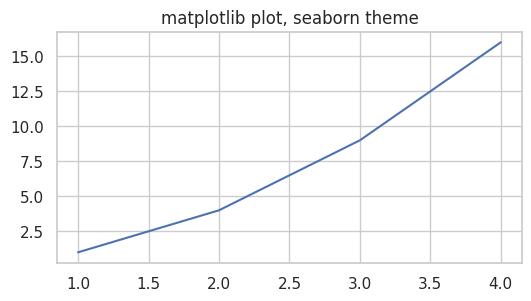

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

# Quick sanity check — a plain matplotlib plot now uses seaborn defaults.
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([1, 2, 3, 4], [1, 4, 9, 16])
ax.set_title("matplotlib plot, seaborn theme")
plt.show()

Note the gridlines, font, and color. We did not call seaborn for the
plot itself — `sns.set_theme()` just changed Matplotlib's defaults.

If you ever want the original Matplotlib look back:
```python
plt.style.use("default")
```


## Built-in datasets

Seaborn ships with small datasets for teaching. They live online and load
on first call. We use `penguins` throughout this series.


In [3]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
# Shape and dtypes — always check these for a new dataset.
print(penguins.shape)
print()
print(penguins.dtypes)

(344, 7)

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


In [5]:
# Missing values — penguins has a few. Most seaborn functions handle
# them by dropping rows internally, but it's good to know.
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## The first seaborn plot

`scatterplot` takes a DataFrame and column names. Compare this to the
Matplotlib version below.


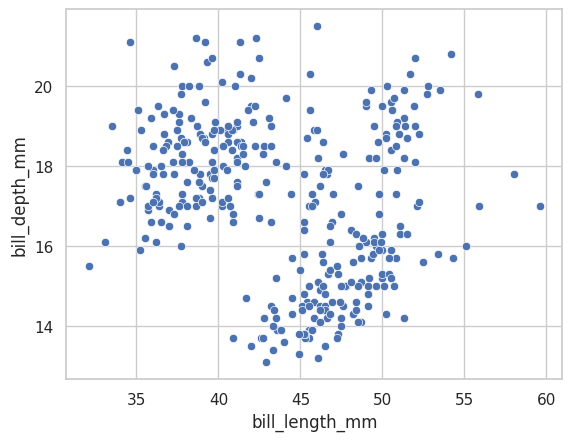

In [6]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")
plt.show()

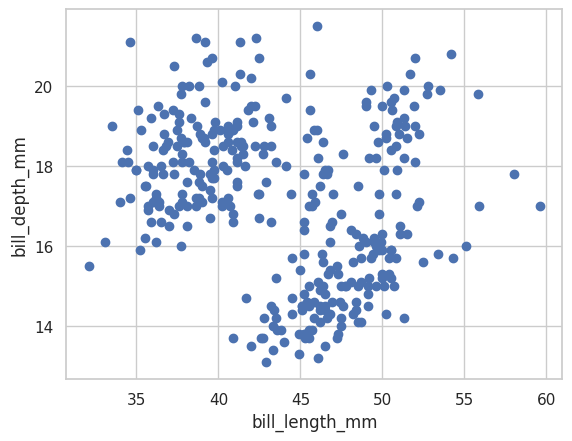

In [7]:
# The Matplotlib equivalent. More verbose, no automatic legend handling
# if we wanted to color by species (we'll see that next).
plt.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"])
plt.xlabel("bill_length_mm")
plt.ylabel("bill_depth_mm")
plt.show()

## The `hue` parameter — seaborn's killer feature

`hue` colors points by a categorical column. In Matplotlib you would loop
over categories and call `plt.scatter` multiple times. In seaborn it is
one argument.


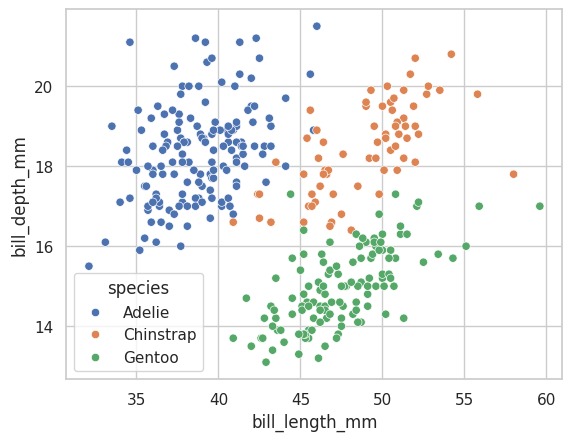

In [8]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
)
plt.show()

The three penguin species separate cleanly in bill space. The legend
appears automatically.

Two more encoding channels work the same way:

- `size` — varies marker size by a column (numeric or categorical).
- `style` — varies marker shape by a categorical column.

You can use all three at once, but readers usually cannot decode more
than two encodings at a glance.


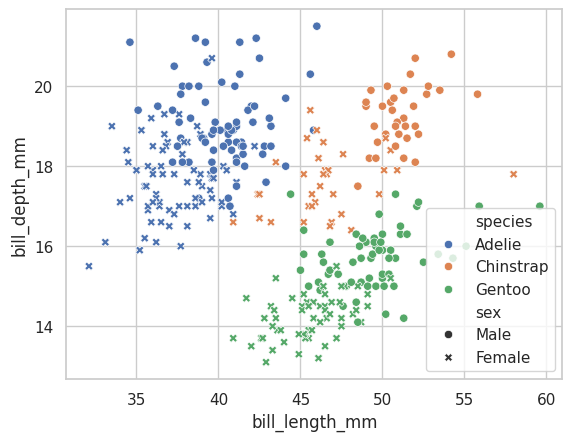

In [9]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="sex",
)
plt.show()

## Long-format data — the rule that explains everything

Seaborn expects data in **long format**: one row per observation, with
categorical variables as columns rather than spread across columns.
The key characteristics are:

    One row per observation: Every individual data point gets its own row.
    Categorical variables as columns: Instead of having columns like 'City_2020_rainfall' and 'City_2021_rainfall', you'd have a 'City' column and a 'Year' column, with the 'rainfall_mm' in another column.

Penguins is already in long format. Each row is one penguin; species and
sex are columns, not separate sub-tables.

Wide format is the alternative — categories spread across columns. It
looks natural in spreadsheets but seaborn cannot use it directly.


In [10]:
# Long format (what seaborn wants). One row per measurement.
long_df = pd.DataFrame({
    "city": ["Karachi", "Karachi", "Lahore", "Lahore", "Islamabad", "Islamabad"],
    "year": [2020, 2021, 2020, 2021, 2020, 2021],
    "rainfall_mm": [167, 142, 540, 612, 750, 820],
})
long_df

,city,year,rainfall_mm
0,Karachi,2020,167
1,Karachi,2021,142
2,Lahore,2020,540
3,Lahore,2021,612
4,Islamabad,2020,750
5,Islamabad,2021,820


In [11]:
# Wide format — the same data, but cities as columns.
# Readable for humans, awkward for seaborn.
wide_df = long_df.pivot(index="year", columns="city", values="rainfall_mm")
wide_df

city,Islamabad,Karachi,Lahore
year,,,
2020,750,167,540
2021,820,142,612


To plot the wide version with seaborn, you melt it back to long:


In [12]:
melted = wide_df.reset_index().melt(
    id_vars="year",
    var_name="city",
    value_name="rainfall_mm",
)
melted

,year,city,rainfall_mm
0,2020,Islamabad,750
1,2021,Islamabad,820
2,2020,Karachi,167
3,2021,Karachi,142
4,2020,Lahore,540
5,2021,Lahore,612


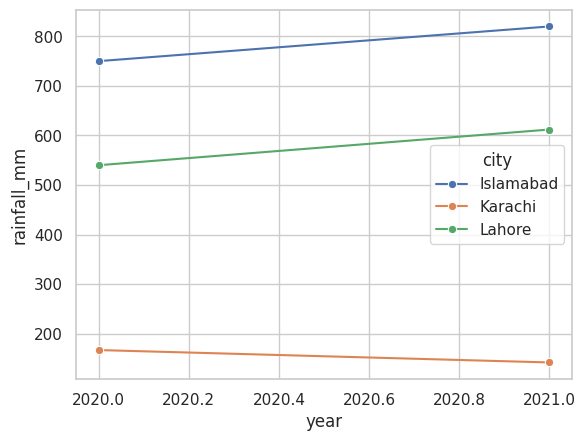

In [13]:
sns.lineplot(data=melted, x="year", y="rainfall_mm", hue="city", marker="o")
plt.show()

Whenever a seaborn plot looks wrong or refuses to color by category,
the answer is usually: your data is in wide format. Use `pd.melt` to
convert.


## Figure-level vs axes-level functions

Every seaborn plotting function is one of two kinds. Knowing which is
which saves a lot of confusion later.

**Axes-level functions** draw onto a single Matplotlib axes. They return
the axes object. Examples: `scatterplot`, `lineplot`, `histplot`, `barplot`.

**Figure-level functions** create their own figure (often with multiple
subplots). They return a `FacetGrid` object, not an axes. Examples:
`relplot`, `displot`, `catplot`, `lmplot`.

The naming is the giveaway: figure-level functions end in `plot` and start
with a category prefix (`rel`, `dis`, `cat`, `lm`).

Practical consequence: figure-level functions take a `col` or `row`
parameter to split the plot into facets. Axes-level functions do not.


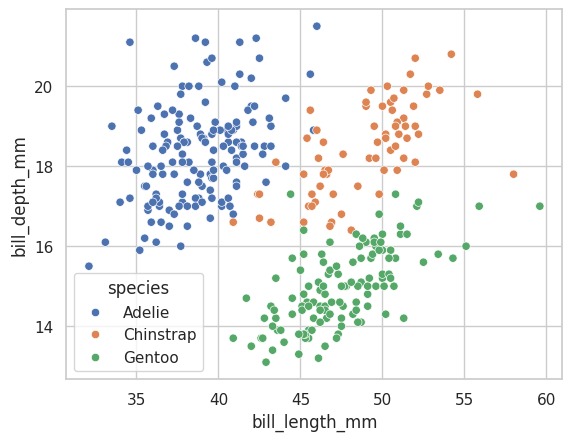

In [14]:
# Axes-level: one plot, one axes.
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.show()

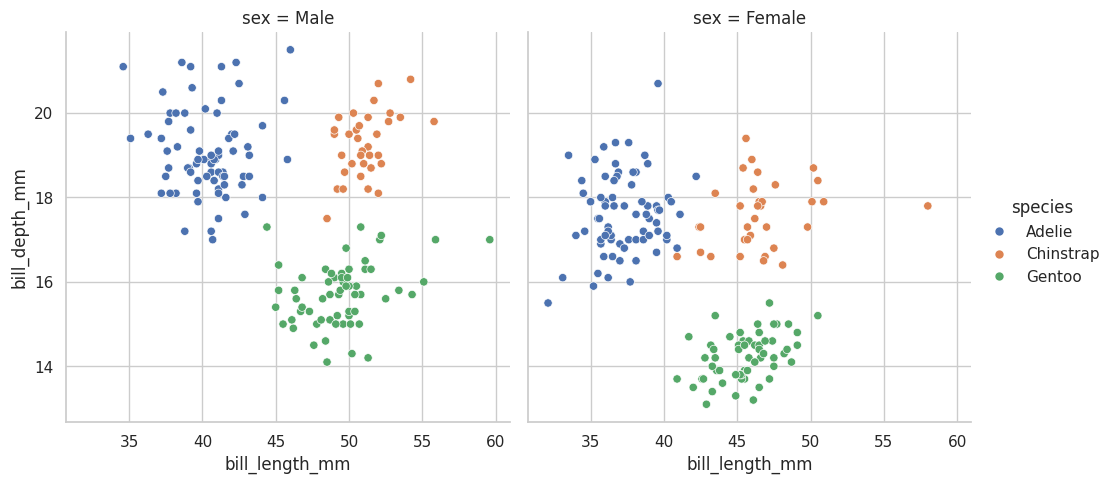

In [15]:
# Figure-level: relplot is the figure-level version of scatterplot.
# Adding col="sex" splits the plot into one panel per sex.
sns.relplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    col="sex",
    kind="scatter",   # relplot defaults to scatter; lineplot equivalent is kind="line"
)
plt.show()

Notice `col="sex"` produced two panels side by side, automatically.
You cannot do this with the axes-level `scatterplot` directly — you would
have to build the subplots yourself.

**Rule of thumb**: use axes-level when you want one plot or are composing
manually with Matplotlib. Use figure-level when you want faceting.


## Mixing seaborn with Matplotlib

Seaborn returns Matplotlib objects, so you can keep customizing.


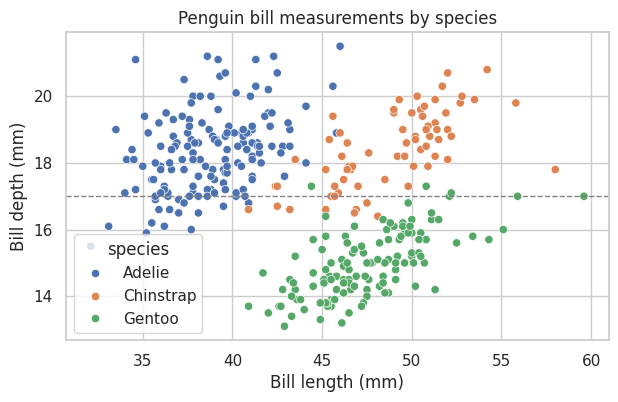

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    ax=ax,             # tell seaborn which axes to draw on
)

# Standard matplotlib customization now works.
ax.set_title("Penguin bill measurements by species")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.axhline(17, color="gray", linestyle="--", linewidth=1)
plt.show()

For figure-level functions this is different — they create their own
figure, so passing `ax` is not allowed. You access the underlying axes
through the returned `FacetGrid`:

```python
g = sns.relplot(...)
g.axes[0, 0].set_title("custom title")
```


A few things that confuse people early.

**1. `sns.set_theme()` is global.** It changes Matplotlib defaults for the
whole session. If you import seaborn but want vanilla Matplotlib styling,
do not call `set_theme()`, or reset with `plt.style.use("default")`.

**2. Seaborn copies your DataFrame internally.** Modifying the original
DataFrame after the plot is built will not change the plot. This is
usually what you want, but it can surprise you if you assumed otherwise.

**3. `hue` requires the column to exist in the DataFrame passed via
`data=`.** Common mistake: passing `x=df["col"]` and `hue="other"` will fail
because seaborn has no DataFrame to look up `"other"` in. Always pass
`data=df` and use string column names.

**4. Figure-level functions ignore `ax=`.** They build their own figure.
Trying to pass `ax` to `relplot` or `displot` raises an error.

**5. Missing values are dropped silently in most plots.** If your sample
size looks wrong, check `df.isna().sum()`.
